# How to use

> Designing a template region, calling genotypes from sequencing data, and visualizing mutation profiles.

A DGRec experiment has two computational halves, and this page follows them in order.

**Before the experiment**, you choose a template region (TR) — the part of the dgrRNA that the
reverse transcriptase copies. Most sequences make poor TRs, so it is worth scoring a candidate,
and recoding it if necessary, before building anything.

**After the experiment**, you sequence the variable region (VR) amplicon and measure what the
mutagenesis actually produced: which genotypes appeared, and where along the sequence the
mutations fell.

Everything below runs as written: the package ships with a small example dataset.

## Before the experiment: designing a TR

The TR is a segment of the dgrRNA, a small non-coding RNA, and it is the part the reverse
transcriptase copies into the mutagenic cDNA. Not every sequence works: whether the RT can read
the dgrRNA depends on how that RNA folds, and a TR that folds badly is simply not mutagenized.
`tr_score` predicts this from the folding energy, on a scale from 0 (poor) to 1 (good).

In [ ]:
import dgrec

In [ ]:
TR_bad  = 'TTAGCGAATGGCGAAATTCGTAAACGCCCTCTGATCGAAACCAACGGCGAAACGGGTGAGATCGTGTGGG'
TR_good = 'AAATGATCGCCAAATCTGAACAGGAAATTGGCAAAGCAACCGCTAAATACTTTTTCTACTCAAACATTAT'

print('bad TR  score =', dgrec.tr_score(TR_bad))
print('good TR score =', dgrec.tr_score(TR_good))

bad TR  score = 0.23
good TR score = 0.84


A TR that scores poorly can often be rescued by changing a few of its bases. Two things shape the choice.

The first is the protein. The TR is read in the reading frame of the gene that carries the VR, and that protein has to survive the diversification, so the substitutions are chosen to be synonymous for it.

The second is homology. The cDNA recombines with the VR because the two are alike, so changing the TR alone makes them less alike. This is allowed — nothing forbids recoding the TR on its own — but it is a trade: a recoded TR is reverse-transcribed more efficiently while recombining less efficiently, and the two effects can cancel, leaving the overall mutagenesis no better than before. Introducing the same substitutions into the VR keeps the pair matched and avoids the trade altogether.

`optimize_sequence` searches for substitutions that are synonymous in that reading frame and that improve the predicted folding of the dgrRNA. It returns one row per candidate, ranked, each with the recoded sequence and its two scores.

In [ ]:
import pandas as pd
from dgrec.predictions import optimize_sequence

variants = optimize_sequence(TR_bad, N=5, CHANGES=6)
pd.DataFrame(variants)[['New_Variant', 'Score_TRSp', 'Score_TRSpAvd']]

,New_Variant,Score_TRSp,Score_TRSpAvd
0,TTAGCGAACGGCGAAATCCGTAAACGCCCTCTGATCGAAACCAACG...,0.74,0.79
1,TTAGCGAATGGCGAAATCCGTAAACGCCCTCTGATCGAAACCAACG...,0.66,0.81
2,TTAGCGAATGGTGAAATCCGTAAACGCCCTCTGATCGAAACCAACG...,0.64,0.82
3,TTAGCGAACGGTGAAATTCGTAAACGCCCTCTGATCGAAACCAACG...,0.62,0.81
4,TTAGCGAATGGCGAAATCCGTAAACGCCCTCTGATCGAAACCAATG...,0.58,0.78


### Directing diversification to chosen positions

The reverse transcriptase makes its errors at adenines, so the adenines of the TR are where
diversity appears. Which positions diversify is therefore not fixed: it follows from where the
adenines are, and you can put them where you want them.

This is the one case where it is useful *not* to mirror a change into the VR. Introducing
adenines into the TR alone leaves a deliberate mismatch at that codon, which is the point —
the cDNA carries the variation into the VR, and the protein is diversified exactly there. The homology
cost is the same one as before, but paid deliberately at a few chosen codons rather than spread
along the whole sequence.

The codon to reach for is **AAC** (asparagine). It carries two adenines, and because its third
base is a C no combination of adenine substitutions can turn it into a stop codon — so a molecule
can reach 15 of the 20 amino acids at that position with no risk of truncating the protein.
`AAT`, the other asparagine codon, is equivalent on both counts. The obvious alternative, the
lysine codon `AAA`, reaches every amino acid but can also become `TAA`, `TAG` or `TGA`, which
truncates the protein — the constraint discussed in the paper.

`optimize_sequence` takes a `diversify` argument for this, keyed by **codon index** (not
nucleotide position, unlike `forbidden_positions`). Each entry says what should happen at that
codon:

- `'max'` or `'min'` — tune how many amino acids the position can reach, without constraining
  which ones. `'max'` is the shortcut for the paragraph above: the optimiser writes `AAC` into
  that codon, locks it, and optimises the folding around it. This changes the protein at that
  position, deliberately, since that is the residue you have chosen to diversify.
- `['Y', 'F']` — the codon must be able to reach all of these amino acids.
- `('min', ['K', 'R'])` — both: reach these, and among the codons that can, take the one that
  brings along the fewest others. Use this to open a position towards a particular chemistry
  without letting the rest of the amino acid space in.

In [ ]:
from dgrec.utils import CODON_TO_AA

#codon 7 of TR_bad is AAA (lysine): it diversifies widely, but can also be truncated
best = optimize_sequence(TR_bad, diversify={7: 'max'}, CHANGES=4, N=1)[0]

before, after = TR_bad[21:24], best['New_Variant'][21:24]
print(f"codon 7: {before} ({CODON_TO_AA[before]}) -> {after} ({CODON_TO_AA[after]})")
print(f"folding scores: {best['Score_TRSp']} / {best['Score_TRSpAvd']}")

codon 7: AAA (K) -> AAC (N)
folding scores: 0.74 / 0.78


The same machinery is available alongside the LSTM model as
`dgrec.lstm.optimize_sequence_display_proteins`, which additionally shows the amino acid
distribution each candidate TR is predicted to generate.

`optimize_sequence` is documented in full in the [predictions API](API/predictions.html).


## After the experiment: calling genotypes

Genotype calling takes the amplicon reads and a reference sequence, groups the reads by their
UMI so that PCR and sequencing errors are averaged out within a molecule, and reports the
distinct genotypes it finds. It is available both as a command-line tool and as a Python
function; the two do the same work.

### From the command line

#### Single reads

```sh
dgrec genotypes fastq_path reference_path -o genotypes.csv
```

In [ ]:
#|filter_stream BiopythonWarning BiopythonDeprecationWarning warnings.warn
#|echo: false
!dgrec genotypes --help

Usage: dgrec genotypes [OPTIONS] FASTQ REF

Options:
  -u, --umi_size INTEGER          Number of nucleotides at the beginning of
                                  the read that will be used as the UMI
  -q, --quality_threshold INTEGER
                                  threshold value used to filter out reads of
                                  poor average quality
  -i, --ignore_pos LIST           list of positions that are ignored in the
                                  genotype, e.g. [0,1,149,150]
  --match FLOAT                   match parameter of the aligner
  --mismatch FLOAT                mismatch parameter of the aligner
  --gap_open FLOAT                gap_open parameter of the aligner
  --gap_extend FLOAT              gap_extend parameter of the aligner
  -r, --reads_per_umi_thr INTEGER
                                  minimum number of reads required to take a
                                  UMI into account. Using a number >2 enables
                                 

#### Paired reads


```sh
dgrec genotypes_paired fwd_fastq_path rev_fastq_path reference_path --fwd_span 0 150 --rev_span 30 150 -o genotypes.csv
```

In [ ]:
#|filter_stream BiopythonWarning BiopythonDeprecationWarning warnings.warn
#|echo: false
!dgrec genotypes_paired --help

Usage: dgrec genotypes_paired [OPTIONS] FASTQ_FWD FASTQ_REV REF

  Calls dgrec.genotypes_paired.get_genotypes_paired

Options:
  --fwd_span <INTEGER INTEGER>...
                                  Span of the reference sequence read in the
                                  forward orientation format: start end
                                  [required]
  --rev_span <INTEGER INTEGER>...
                                  Span of the reference sequence read in the
                                  reverse orientation format: start end
                                  [required]
  -p, --require_perfect_pair_agreement
                                  Require perfect pair agreement for genotype
                                  calling (default: True).                  If
                                  set to False, the forward sequence will be
                                  used in case of disagreement.
  -u1, --umi_size_fwd INTEGER     Number of nucleotides at the beginning of
    

### In Python

The Python interface gives the genotypes back as a list, which is more convenient when the
result feeds into further analysis.

The package bundles a small example dataset so that everything below can be run as written. `dgrec.get_example_data_dir()` returns its path; it contains `sacB_example.fastq.gz` and `sacB_ref.fasta` used here, a paired-end example, and the trained models.

In [ ]:
#The package ships with a small example dataset; this is where it lives
data_path = dgrec.get_example_data_dir()

Load the reference and call the genotypes. `ignore_pos` excludes positions at the edges of the
amplicon, where sequencing quality is low and spurious mismatches accumulate.

In [ ]:
from Bio import SeqIO
import os

#Getting the path to the fastq file
fastq_file="sacB_example.fastq.gz"
fastq_path=os.path.join(data_path,fastq_file)

#Getting the reference sequence for the amplicon
read_ref_file="sacB_ref.fasta"
ref=next(SeqIO.parse(os.path.join(data_path,read_ref_file),"fasta"))
ref_seq=str(ref.seq)

#Genotypes, sorted by the number of UMI-deduplicated molecules supporting each one
genotypes = dgrec.get_genotypes(fastq_path, ref_seq, ignore_pos=[0,1,2,138,139,140,141],
                                as_dataframe=True)
genotypes.head(10)

n reads:	1000
n_reads pass filter:	847
n_reads aligned:	824
Number of UMIs: 814
Median number of reads per UMI: 1.0
Number of genotypes: 123


,genotype,count
0,,675
1,C56A,3
2,A76G,3
3,A91G,3
4,A91T,3
5,C69T,2
6,T122A,2
7,A91C,2
8,A105G,2
9,C116A,2


Each genotype is represented as a comma-separated list of mutations in the format `[RefBase][Position][AltBase]`. The table is sorted by the number of UMI-deduplicated molecules supporting each genotype. The first entry is typically the wild-type (unmutated) sequence, whose genotype string is empty.

Without `as_dataframe=True` the same result comes back as a list of `(genotype, count)` tuples; both forms are accepted everywhere the package takes a genotype list.

## Visualizing mutation profiles

Plot mutation counts at each position. The shaded region indicates the TR range, where DGRec mutagenesis is active. Note the strong enrichment of mutations at adenine positions within the TR — the hallmark DGRec signature (in this example the TR was designed to have an identical sequence to the VR).

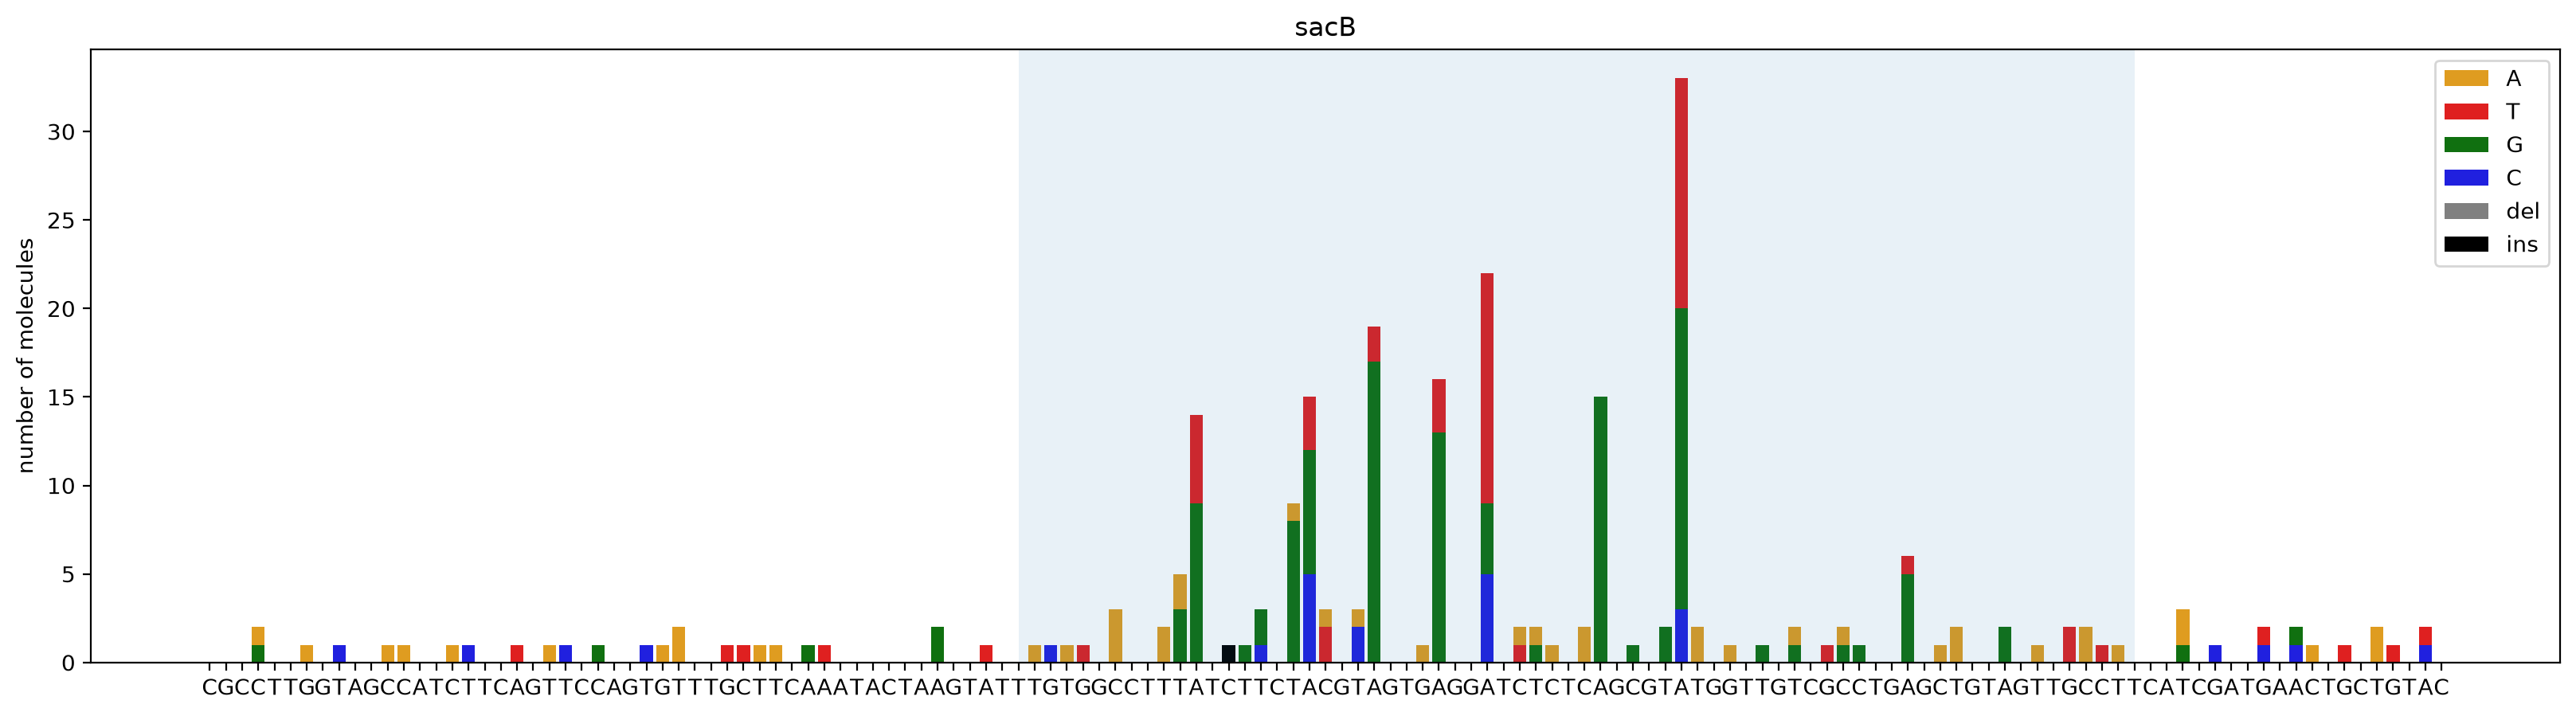

In [ ]:
fig = dgrec.plot_mutations(genotypes, ref_seq, sample_name="sacB", TR_range=[50,119])

## Where to go next

- [API reference](API/genotypes.html) — every function, with its arguments and defaults.
- [`dgrec.lstm`](API/lstm.html) — the LSTM model of the RT error profile, for predicting which
  variants a TR will generate. It needs the `lstm` extra.
- [Library size estimation](DGRec%20data%20analysis/library_size_estimation.html) — how many
  distinct variants a library of a given size is expected to contain.